# Notebook 00 - Fondations

**Surface de volatilité implicite sans arbitrage — mémoire de master**

Ce notebook est la *brique de base* de tout le projet. On y construit, en partant de zéro et en expliquant chaque étape côté finance, les outils réutilisés partout ensuite :

1. **Black-Scholes** et **inversion de la volatilité implicite** (prix → σ).
2. Les **bonnes coordonnées** : log-moneyness $k$ et variance totale $w$.
3. La paramétrisation **SVI** pour fabriquer des smiles dont on contrôle tout.
4. Les **conditions de non-arbitrage statique**, rendues concrètes et *calculables* :
   - *butterfly* ⟺ densité risque-neutre positive ⟺ $g(k)\ge 0$,
   - *calendar* ⟺ la variance totale croît avec la maturité.
5. Un **test grandeur nature** : détecter un vrai arbitrage (exemple d'Axel Vogt, tiré de Gatheral & Jacquier 2014).
6. Un **générateur de surface complète sans arbitrage** (SSVI) — notre future *vérité-terrain*.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (7, 4.2)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
RNG = np.random.default_rng(0)


## 1. Black-Scholes et volatilité implicite

### Le pricing
On se place en **mesure forward** pour simplifier : on raisonne sur le prix *forward* $F$ du sous-jacent et un facteur d'actualisation $D$ (qu'on prendra $=1$ pour les données synthétiques). Le prix d'un call européen de strike $K$, maturité $\tau$, volatilité $\sigma$ est (formule de Black) :

$$ C = D\,[\,F\,N(d_1) - K\,N(d_2)\,], \qquad d_{1,2} = \frac{\ln(F/K) \pm \tfrac12\sigma^2\tau}{\sigma\sqrt{\tau}}. $$

$N$ est la fonction de répartition de la loi normale. Le put s'en déduit par parité call-put.

### La volatilité implicite, c'est une *inversion*
Black-Scholes suppose $\sigma$ **constante**. Mais sur le marché on observe des *prix*, pas des volatilités. La **volatilité implicite** $\sigma_{\mathrm{IV}}(K,\tau)$ est définie comme l'unique $\sigma$ telle que le prix Black-Scholes égale le prix de marché :

$$ C_{\text{Black}}(F,K,\tau,\sigma_{\mathrm{IV}}) = C_{\text{marché}}. $$

Comme $C$ est *strictement croissant* en $\sigma$ (le **véga** est positif), l'inversion est bien posée et se résout numériquement. Le fait que $\sigma_{\mathrm{IV}}$ **dépende** de $K$ et $\tau$ — alors que Black-Scholes la voudrait constante — est exactement ce qui crée le *smile* et la *surface*.


In [2]:
def bs_price(F, K, tau, sigma, D=1.0, option="call"):
    """Prix Black (forward) d'une option europeenne.

    F : forward du sous-jacent, K : strike, tau : maturite (annees),
    sigma : volatilite, D : facteur d'actualisation, option : 'call' ou 'put'.
    Vectorise sur des arrays numpy.
    """
    F, K, tau, sigma = map(np.asarray, (F, K, tau, sigma))
    sqrt_t = np.sqrt(tau)
    d1 = (np.log(F / K) + 0.5 * sigma**2 * tau) / (sigma * sqrt_t)
    d2 = d1 - sigma * sqrt_t
    if option == "call":
        return D * (F * norm.cdf(d1) - K * norm.cdf(d2))
    elif option == "put":
        return D * (K * norm.cdf(-d2) - F * norm.cdf(-d1))
    raise ValueError("option must be 'call' or 'put'")


def bs_vega(F, K, tau, sigma, D=1.0):
    """Sensibilite du prix a sigma (toujours > 0 pour tau, sigma > 0)."""
    d1 = (np.log(F / K) + 0.5 * sigma**2 * tau) / (sigma * np.sqrt(tau))
    return D * F * norm.pdf(d1) * np.sqrt(tau)


In [3]:
def implied_vol(price, F, K, tau, D=1.0, option="call",
                lo=1e-6, hi=5.0):
    """Inverse Black-Scholes : retrouve sigma a partir d'un prix.

    Robuste : bornes d'arbitrage + recherche de racine par brentq.
    Retourne np.nan si le prix est hors des bornes de non-arbitrage.
    """
    # bornes sans arbitrage sur le prix (forward)
    if option == "call":
        intrinsic = D * max(F - K, 0.0)
        upper = D * F
    else:
        intrinsic = D * max(K - F, 0.0)
        upper = D * K
    if not (intrinsic - 1e-12 <= price <= upper + 1e-12):
        return np.nan  # prix arbitrable -> pas de IV valide

    f = lambda s: bs_price(F, K, tau, s, D, option) - price
    flo, fhi = f(lo), f(hi)
    if flo * fhi > 0:           # pas de changement de signe -> pas de racine
        return np.nan
    return brentq(f, lo, hi, xtol=1e-10, rtol=1e-12)


# Test "aller-retour" : sigma -> prix -> sigma doit redonner sigma.
F, K, tau = 1.0, 1.1, 0.5
sig_true = 0.27
px = bs_price(F, K, tau, sig_true)
sig_back = implied_vol(float(px), F, K, tau)
print(f"sigma vrai     = {sig_true:.6f}")
print(f"prix call      = {float(px):.6f}")
print(f"sigma reconstruit = {sig_back:.6f}")
print(f"erreur         = {abs(sig_back - sig_true):.2e}")


sigma vrai     = 0.270000
prix call      = 0.039563
sigma reconstruit = 0.270000
erreur         = 2.88e-14


## 2. Les coordonnées qui simplifient tout : $k$ et $w$

Deux changements de variables rendent toute la théorie du non-arbitrage *beaucoup* plus simple.

**Log-moneyness** : au lieu du strike brut $K$, on travaille avec
$$ k = \ln\!\left(\frac{K}{F}\right). $$
$k=0$ correspond à l'option *at-the-money forward*, $k<0$ aux puts profonds, $k>0$ aux calls profonds. Centrer le smile sur le forward est indispensable (sinon il est décalé et faux).

**Variance totale** : au lieu de la volatilité $\sigma$, on utilise
$$ w(k,\tau) = \sigma_{\mathrm{IV}}^2(k,\tau)\,\tau. $$
Pourquoi ? Parce que les conditions d'absence d'arbitrage s'expriment de façon *propre* en $w$ : l'arbitrage *calendaire* devient simplement « $w$ croît avec $\tau$ », et l'arbitrage *butterfly* s'écrit avec les dérivées de $w$ par rapport à $k$. C'est l'espace naturel de SVI et de tout le reste.


In [4]:
def log_moneyness(K, F):
    return np.log(np.asarray(K) / F)

def total_variance(sigma_iv, tau):
    return np.asarray(sigma_iv) ** 2 * np.asarray(tau)

def iv_from_total_variance(w, tau):
    return np.sqrt(np.asarray(w) / np.asarray(tau))


## 3. SVI : une surface paramétrique pour tout contrôler

**SVI** (*Stochastic Volatility Inspired*, Gatheral 2004) paramétrise la variance totale d'une *tranche* (une maturité fixée) par 5 paramètres. Forme *raw* :

$$ w(k) = a + b\Big(\rho\,(k-m) + \sqrt{(k-m)^2 + \sigma^2}\Big). $$

Interprétation des paramètres :
- $a$ : niveau global (décale la variance vers le haut/bas) ;
- $b$ : pente des ailes (plus $b$ grand, plus les ailes montent) ;
- $\rho \in [-1,1]$ : asymétrie gauche/droite (le *skew*) ;
- $m$ : translation horizontale (recentre le smile) ;
- $\sigma > 0$ : aplatit le creux à la monnaie.

SVI a des **dérivées en forme close**, ce qui est précieux : on pourra calculer la condition de non-arbitrage *exactement*, sans approximation.

$$ w'(k) = b\!\left(\rho + \frac{k-m}{\sqrt{(k-m)^2+\sigma^2}}\right),\qquad
   w''(k) = \frac{b\,\sigma^2}{\big((k-m)^2+\sigma^2\big)^{3/2}}. $$


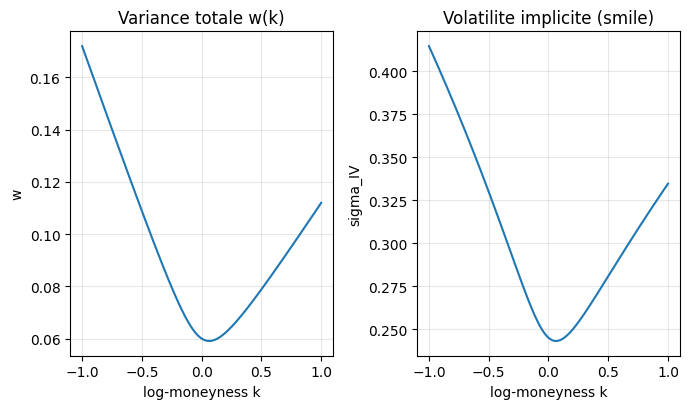

In [5]:
def svi_raw(k, a, b, rho, m, sigma):
    """Variance totale SVI (forme raw)."""
    k = np.asarray(k, dtype=float)
    return a + b * (rho * (k - m) + np.sqrt((k - m) ** 2 + sigma ** 2))

def svi_raw_prime(k, a, b, rho, m, sigma):
    k = np.asarray(k, dtype=float)
    return b * (rho + (k - m) / np.sqrt((k - m) ** 2 + sigma ** 2))

def svi_raw_double_prime(k, a, b, rho, m, sigma):
    k = np.asarray(k, dtype=float)
    return b * sigma ** 2 / ((k - m) ** 2 + sigma ** 2) ** 1.5


# Un smile SVI "raisonnable" pour une maturite tau = 1 an.
params_ok = dict(a=0.04, b=0.10, rho=-0.30, m=0.00, sigma=0.20)
tau = 1.0
k_grid = np.linspace(-1.0, 1.0, 401)
w = svi_raw(k_grid, **params_ok)
iv = iv_from_total_variance(w, tau)

fig, ax = plt.subplots(1, 2)
ax[0].plot(k_grid, w); ax[0].set(title="Variance totale w(k)", xlabel="log-moneyness k", ylabel="w")
ax[1].plot(k_grid, iv); ax[1].set(title="Volatilite implicite (smile)", xlabel="log-moneyness k", ylabel="sigma_IV")
plt.tight_layout(); plt.show()


## 4. Le non-arbitrage, rendu concret

C'est le cœur conceptuel du sujet. Une surface mal construite peut impliquer des prix qui offrent un gain sans risque. Il faut bannir deux arbitrages *statiques*.

### 4a. Butterfly ⟺ densité positive ⟺ $g(k)\ge 0$

Les prix d'options d'une maturité encodent une **densité de probabilité risque-neutre** $p$ du sous-jacent (résultat de Breeden-Litzenberger : $p \propto \partial^2 C/\partial K^2$). Une densité *négative* est absurde et arbitrable. Gatheral & Jacquier montrent que, en variance totale, la densité s'écrit

$$ p(k) = \frac{g(k)}{\sqrt{2\pi\,w(k)}}\,\exp\!\Big(\!-\tfrac12 d_-(k)^2\Big),\qquad d_-(k) = -\frac{k}{\sqrt{w(k)}} - \frac{\sqrt{w(k)}}{2}, $$

où la fonction de **Durrleman** est

$$ g(k) = \left(1 - \frac{k\,w'(k)}{2\,w(k)}\right)^2 - \frac{w'(k)^2}{4}\left(\frac{1}{w(k)} + \frac14\right) + \frac{w''(k)}{2}. $$

Comme tout le reste est positif, **la densité est positive si et seulement si $g(k)\ge 0$ pour tout $k$**. C'est *la* condition butterfly, et elle ne fait intervenir que $w, w', w''$ — donc parfaitement calculable par autodifférenciation dans un réseau plus tard.

### 4b. Calendar ⟺ $w$ croît avec la maturité

Pas d'arbitrage calendaire $\iff$ la variance totale est **non décroissante en $\tau$** à $k$ fixé :
$$ \frac{\partial w(k,\tau)}{\partial \tau} \ge 0. $$
Visuellement : en traçant $w(\cdot,\tau)$ pour plusieurs maturités, **les courbes ne doivent jamais se croiser** (une maturité plus longue est toujours au-dessus).


In [6]:
def durrleman_g(k, w, wp, wpp):
    """Fonction de Durrleman g(k).

    g(k) >= 0 pour tout k  <=>  densite risque-neutre positive
                             <=>  pas d'arbitrage butterfly.
    """
    return (1 - k * wp / (2 * w)) ** 2 - (wp ** 2 / 4) * (1 / w + 0.25) + wpp / 2


def risk_neutral_density(k, w, wp, wpp):
    """Densite risque-neutre implicite en log-moneyness."""
    g = durrleman_g(k, w, wp, wpp)
    d_minus = -k / np.sqrt(w) - np.sqrt(w) / 2
    return g / np.sqrt(2 * np.pi * w) * np.exp(-0.5 * d_minus ** 2)


def svi_diagnostics(k, **p):
    """Renvoie (w, w', w'', g, densite) pour des parametres SVI raw."""
    w = svi_raw(k, **p)
    wp = svi_raw_prime(k, **p)
    wpp = svi_raw_double_prime(k, **p)
    g = durrleman_g(k, w, wp, wpp)
    dens = risk_neutral_density(k, w, wp, wpp)
    return w, wp, wpp, g, dens


min g(k) = 0.3710   -> OK (>=0)


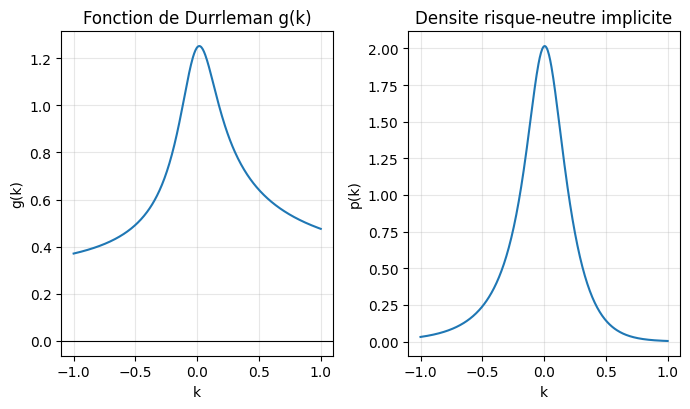

In [7]:
# Diagnostic butterfly sur notre smile "raisonnable"
w0, wp0, wpp0, g0, dens0 = svi_diagnostics(k_grid, **params_ok)
print(f"min g(k) = {g0.min():.4f}   -> {'OK (>=0)' if g0.min() >= 0 else 'ARBITRAGE'}")

fig, ax = plt.subplots(1, 2)
ax[0].axhline(0, color="k", lw=0.8)
ax[0].plot(k_grid, g0); ax[0].set(title="Fonction de Durrleman g(k)", xlabel="k", ylabel="g(k)")
ax[1].plot(k_grid, dens0); ax[1].set(title="Densite risque-neutre implicite", xlabel="k", ylabel="p(k)")
plt.tight_layout(); plt.show()


## 5. Test grandeur nature : détecter un *vrai* arbitrage

Voici l'intérêt d'avoir codé $g(k)$ : on peut **prouver** qu'un jeu de paramètres est arbitrable. On reprend l'exemple célèbre d'**Axel Vogt** cité dans Gatheral & Jacquier (2014), avec

$$ (a,b,m,\rho,\sigma) = (-0.0410,\ 0.1331,\ 0.3586,\ 0.3060,\ 0.4153),\quad \tau = 1. $$

Le papier annonce que ce smile, pourtant d'allure parfaitement normale, cache une densité **négative**. Nos diagnostics doivent le détecter : on s'attend à voir $g(k)$ passer sous zéro et la densité devenir négative.


min g(k)        = -0.0329  -> ARBITRAGE detecte !
min densite     = -0.0001
zone arbitrable : k in [0.645, 1.000]


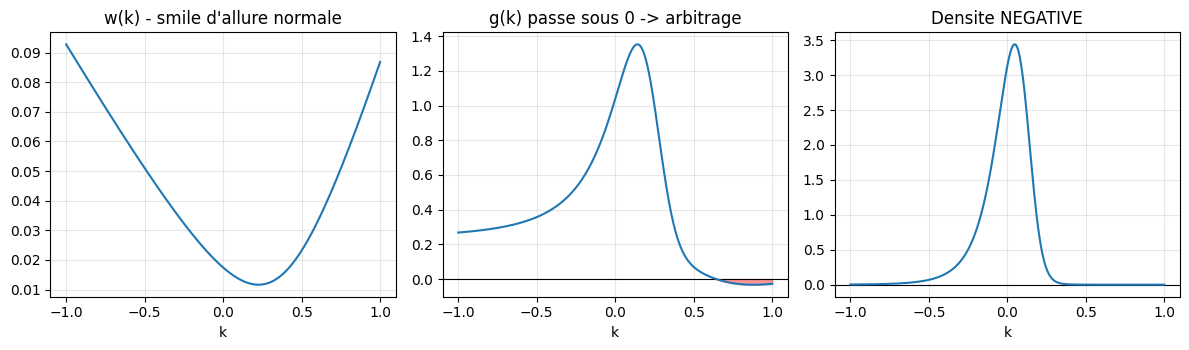

In [8]:
params_vogt = dict(a=-0.0410, b=0.1331, rho=0.3060, m=0.3586, sigma=0.4153)
wv, wpv, wppv, gv, densv = svi_diagnostics(k_grid, **params_vogt)

print(f"min g(k)        = {gv.min():.4f}  -> {'OK' if gv.min() >= 0 else 'ARBITRAGE detecte !'}")
print(f"min densite     = {densv.min():.4f}")
print(f"zone arbitrable : k in [{k_grid[gv < 0].min():.3f}, {k_grid[gv < 0].max():.3f}]")

fig, ax = plt.subplots(1, 3, figsize=(12, 3.6))
ax[0].plot(k_grid, wv); ax[0].set(title="w(k) - smile d'allure normale", xlabel="k")
ax[1].axhline(0, color="k", lw=0.8); ax[1].plot(k_grid, gv)
ax[1].fill_between(k_grid, gv, 0, where=gv < 0, color="red", alpha=0.4)
ax[1].set(title="g(k) passe sous 0 -> arbitrage", xlabel="k")
ax[2].axhline(0, color="k", lw=0.8); ax[2].plot(k_grid, densv)
ax[2].fill_between(k_grid, densv, 0, where=densv < 0, color="red", alpha=0.4)
ax[2].set(title="Densite NEGATIVE", xlabel="k")
plt.tight_layout(); plt.show()


**Lecture du résultat.** Le smile $w(k)$ semble irréprochable à l'œil nu, mais $g(k)$ devient négatif sur une plage de $k$, et la densité implicite y est négative : c'est un arbitrage butterfly bien réel. C'est *exactement* pour empêcher ça que les méthodes de la littérature (SVI sans arbitrage, réseaux contraints par les dérivées, opérateurs neuronaux) ajoutent des contraintes. Notre fonction `durrleman_g` sera réutilisée comme **pénalité d'entraînement** et comme **métrique d'évaluation**.

## 6. Une surface complète sans arbitrage : SSVI (notre vérité-terrain)

Pour entraîner et évaluer des modèles, il nous faut des **surfaces entières** dont on *sait* qu'elles sont sans arbitrage. La paramétrisation **SSVI** (*Surface SVI*, Gatheral & Jacquier 2014) relie toutes les tranches via la variance totale à la monnaie $\theta_\tau = w(0,\tau)$ :

$$ w(k,\tau) = \frac{\theta_\tau}{2}\left(1 + \rho\,\varphi(\theta_\tau)\,k + \sqrt{\big(\varphi(\theta_\tau)\,k + \rho\big)^2 + (1-\rho^2)}\right), $$

avec une fonction $\varphi$ (on prend la forme *power-law* $\varphi(\theta)=\eta\,\theta^{-\gamma}$). Sous des conditions simples sur $(\rho,\eta,\gamma)$ et avec $\theta_\tau$ croissant, SSVI est **garanti sans arbitrage statique** (butterfly *et* calendar). On le vérifiera numériquement avec les outils de la section précédente — bouclant proprement la boucle.


In [9]:
def ssvi_phi(theta, eta, gamma):
    """Fonction phi de SSVI (forme power-law)."""
    return eta * theta ** (-gamma)

def ssvi_w(k, theta, rho, eta, gamma):
    """Variance totale SSVI a la maturite dont la variance ATM est theta."""
    k = np.asarray(k, dtype=float)
    phi = ssvi_phi(theta, eta, gamma)
    return 0.5 * theta * (1 + rho * phi * k
                          + np.sqrt((phi * k + rho) ** 2 + (1 - rho ** 2)))

def ssvi_surface(k_grid, taus, theta_of_tau, rho, eta, gamma):
    """Construit la matrice de variance totale w[i, j] = w(k_j, tau_i)."""
    W = np.zeros((len(taus), len(k_grid)))
    for i, t in enumerate(taus):
        W[i] = ssvi_w(k_grid, theta_of_tau(t), rho, eta, gamma)
    return W


In [10]:
# Parametres SSVI sans arbitrage + variance ATM croissante en tau
rho, eta, gamma = -0.5, 0.8, 0.4
theta_of_tau = lambda t: 0.04 * t          # theta croit lineairement -> calendar OK
taus = np.array([0.1, 0.25, 0.5, 1.0, 1.5, 2.0])
k_grid = np.linspace(-1.0, 1.0, 401)

W = ssvi_surface(k_grid, taus, theta_of_tau, rho, eta, gamma)

# --- Verification BUTTERFLY (g >= 0) sur chaque tranche, par derivees numeriques ---
def numerical_g(k, w_func, h=1e-4):
    w   = w_func(k)
    wp  = (w_func(k + h) - w_func(k - h)) / (2 * h)
    wpp = (w_func(k + h) - 2 * w + w_func(k - h)) / h ** 2
    return durrleman_g(k, w, wp, wpp)

min_g_per_slice = []
for t in taus:
    f = lambda kk: ssvi_w(kk, theta_of_tau(t), rho, eta, gamma)
    min_g_per_slice.append(numerical_g(k_grid, f).min())
min_g_per_slice = np.array(min_g_per_slice)
print("min g(k) par maturite :", min_g_per_slice)
print("Butterfly :", "OK partout" if (min_g_per_slice >= -1e-8).all() else "VIOLATION")

# --- Verification CALENDAR : w croissant en tau a chaque k (pas de croisement) ---
calendar_ok = np.all(np.diff(W, axis=0) >= -1e-10)
print("Calendar  :", "OK (w croit en tau)" if calendar_ok else "VIOLATION")


min g(k) par maturite : [0.3132 0.3394 0.3657 0.3986 0.4214 0.4392]
Butterfly : OK partout
Calendar  : OK (w croit en tau)


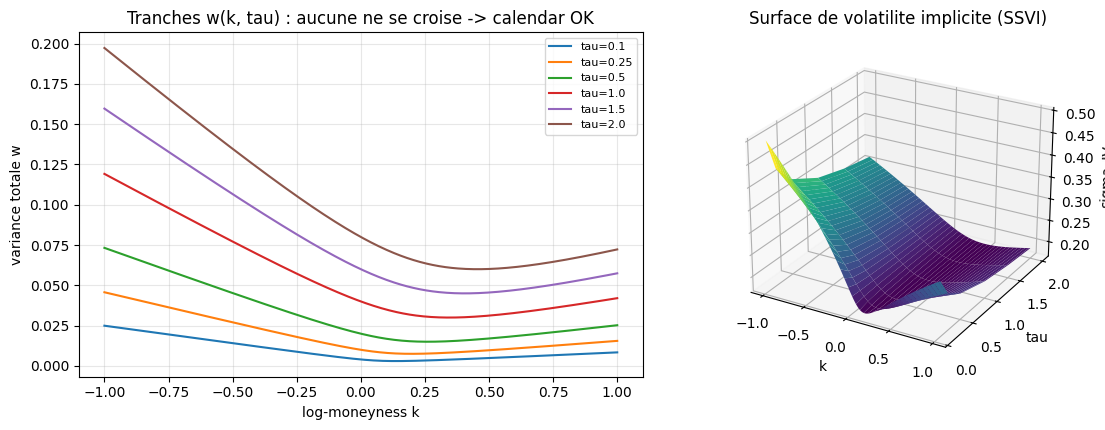

In [11]:
# Visualisation : tranches de variance totale + surface 3D
fig = plt.figure(figsize=(12, 4.4))

ax1 = fig.add_subplot(1, 2, 1)
for i, t in enumerate(taus):
    ax1.plot(k_grid, W[i], label=f"tau={t}")
ax1.set(title="Tranches w(k, tau) : aucune ne se croise -> calendar OK",
        xlabel="log-moneyness k", ylabel="variance totale w")
ax1.legend(fontsize=8)

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
KK, TT = np.meshgrid(k_grid, taus)
IV = np.sqrt(W / TT)                       # surface de volatilite implicite
ax2.plot_surface(KK, TT, IV, cmap="viridis", linewidth=0, antialiased=True)
ax2.set(title="Surface de volatilite implicite (SSVI)",
        xlabel="k", ylabel="tau", zlabel="sigma_IV")
ax2.view_init(elev=25, azim=-60)
plt.tight_layout(); plt.show()


## 7. Échantillonner une grille éparse et irrégulière

Le marché ne donne jamais une grille dense et régulière. Pour rendre nos expériences réalistes (et tester la robustesse à la rareté, comme dans le papier DCNN), on tire un sous-ensemble irrégulier de points $(k,\tau)$ et on y ajoute un bruit d'observation. C'est l'entrée typique d'un problème de *smoothing*.

68 cotations eparses tirees


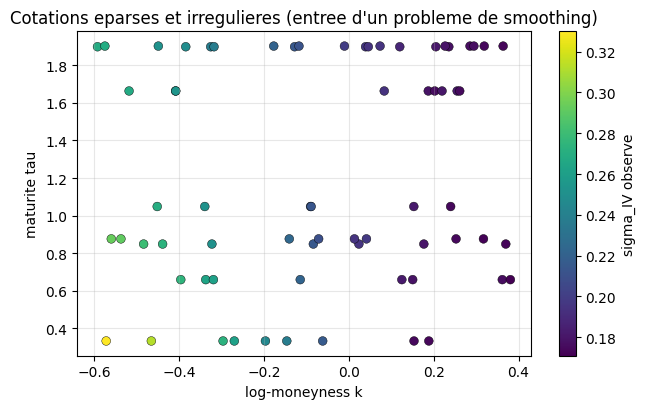

In [12]:
def sample_sparse_quotes(theta_of_tau, rho, eta, gamma,
                          n_per_slice=(5, 12), taus=None,
                          k_range=(-0.6, 0.4), noise=0.0, seed=0):
    """Tire des cotations eparses/irregulieres d'une surface SSVI.

    Renvoie un dict avec k, tau, w_vrai, w_observe (bruite).
    """
    rng = np.random.default_rng(seed)
    if taus is None:
        taus = np.sort(rng.uniform(0.05, 2.0, size=8))
    ks, ts, ws = [], [], []
    for t in taus:
        n = rng.integers(*n_per_slice)
        kk = np.sort(rng.uniform(*k_range, size=n))   # strikes irreguliers
        ww = ssvi_w(kk, theta_of_tau(t), rho, eta, gamma)
        ks.append(kk); ts.append(np.full(n, t)); ws.append(ww)
    k = np.concatenate(ks); tau = np.concatenate(ts); w_true = np.concatenate(ws)
    w_obs = w_true * (1 + noise * rng.standard_normal(w_true.shape))
    return dict(k=k, tau=tau, w_true=w_true, w_obs=w_obs)


quotes = sample_sparse_quotes(theta_of_tau, rho, eta, gamma, noise=0.02, seed=1)
print(f"{len(quotes['k'])} cotations eparses tirees")

plt.figure(figsize=(6.5, 4.2))
sc = plt.scatter(quotes["k"], quotes["tau"], c=np.sqrt(quotes["w_obs"]/quotes["tau"]),
                 cmap="viridis", s=40, edgecolor="k", linewidth=0.3)
plt.colorbar(sc, label="sigma_IV observe")
plt.title("Cotations eparses et irregulieres (entree d'un probleme de smoothing)")
plt.xlabel("log-moneyness k"); plt.ylabel("maturite tau")
plt.tight_layout(); plt.show()


## 8. Récapitulatif — ce qu'on emporte

Les fonctions construites ici forment la **fondation réutilisable** du projet (futur `core/`) :

| Fonction | Rôle |
|---|---|
| `bs_price`, `bs_vega`, `implied_vol` | pricing et inversion IV |
| `log_moneyness`, `total_variance`, `iv_from_total_variance` | changements de coordonnées |
| `svi_raw`, `svi_raw_prime`, `svi_raw_double_prime` | smile paramétrique + dérivées closes |
| `durrleman_g`, `risk_neutral_density` | **diagnostic butterfly** (pénalité + métrique) |
| `ssvi_w`, `ssvi_surface` | générateur de surface **sans arbitrage** (vérité-terrain) |
| `sample_sparse_quotes` | grille éparse/bruitée réaliste |

**Ce qui est acquis et démontré :**
- l'inversion IV est exacte (test aller-retour) ;
- on sait *détecter* un arbitrage butterfly (exemple de Vogt : densité négative capturée) ;
- on sait *générer* des surfaces SSVI dont on vérifie numériquement l'absence d'arbitrage (butterfly + calendar) ;
- on sait fabriquer des cotations éparses réalistes.

**Prochaine étape (Notebook 01).** Calibrer le **benchmark SVI/SSVI** : à partir des `quotes` éparses, retrouver les paramètres par moindres carrés *sous contrainte de non-arbitrage* (`scipy.optimize`, SLSQP), puis mesurer l'erreur de reconstruction et les violations résiduelles avec `durrleman_g`. Ce sera la ligne de référence à battre par le deep learning.
